# Assignment 1 - Matthew Shaver

## Setup

In [1]:
from pathlib import Path
from datetime import datetime

import keras
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from keras import layers
from keras.models import Sequential

print("TF version:", tf.__version__)


TF version: 2.20.0


In [2]:
DATASET_DIR = Path('dogs-vs-cats-classification')
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 65
SEED = 42
CLASS_NAMES = ('cats', 'dogs')
np.random.seed(SEED)

## Dataset

In [3]:
SPLIT_DIR = DATASET_DIR
TRAIN_DIR = SPLIT_DIR / 'train'
VAL_DIR = SPLIT_DIR / 'validation'
TEST_DIR = SPLIT_DIR / 'test'

print('Training cats:', len(list((TRAIN_DIR / 'cats').glob('*.jpg'))))
print('Training dogs:', len(list((TRAIN_DIR / 'dogs').glob('*.jpg'))))
print('Validation cats:', len(list((VAL_DIR / 'cats').glob('*.jpg'))))
print('Validation dogs:', len(list((VAL_DIR / 'dogs').glob('*.jpg'))))
print('Test cats:', len(list((TEST_DIR / 'cats').glob('*.jpg'))))
print('Test dogs:', len(list((TEST_DIR / 'dogs').glob('*.jpg'))))

Training cats: 9977
Training dogs: 9963
Validation cats: 1247
Validation dogs: 1244
Test cats: 1247
Test dogs: 1246


In [4]:
from pathlib import Path
import shutil

folders = [TRAIN_DIR, VAL_DIR, TEST_DIR]
bad_folder = Path('bad_images')
bad_folder.mkdir(exist_ok=True)

bad_files = []

for folder in folders:
    folder = Path(folder)

    for image_path in folder.rglob('*'):
        if image_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            try:
                image_bytes = tf.io.read_file(str(image_path))
                tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
            except Exception:
                bad_files.append(image_path)
                print('Moving bad image:', image_path)

                destination = bad_folder / image_path.name
                if destination.exists():
                    destination = bad_folder / f"{image_path.stem}_{len(bad_files)}{image_path.suffix}"
                shutil.move(str(image_path), str(destination))

print('Total bad images moved:', len(bad_files))

Total bad images moved: 0


## Clean and load the data

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=list(CLASS_NAMES),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=list(CLASS_NAMES),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='binary',
    class_names=list(CLASS_NAMES),
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print('Training batches:', len(train_ds))
print('Validation batches:', len(val_ds))
print('Test batches:', len(test_ds))


Found 19940 files belonging to 2 classes.
Found 2491 files belonging to 2 classes.
Found 2493 files belonging to 2 classes.
Training batches: 307
Validation batches: 39
Test batches: 39


In [ ]:
def plot_learning(history, title):
    metrics = history.history
    epochs = range(1, len(metrics.get('loss', [])) + 1)

    plt.figure(figsize = (12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, metrics.get('loss', []), label = 'train loss')
    plt.plot(epochs, metrics.get('val_loss', []), label = 'val loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, metrics.get('accuracy', []), label = 'train accuracy')
    plt.plot(epochs, metrics.get('val_accuracy', []), label = 'val accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


def make_callbacks(run_name):
    log_dir = Path('outputs') / 'logs' / run_name / datetime.now().strftime('%Y%m%d-%H%M%S')
    log_dir.mkdir(parents = True, exist_ok = True)
    return [
        keras.callbacks.TensorBoard(log_dir = str(log_dir), histogram_freq = 1),
        keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 2, restore_best_weights = True),
    ]


def make_augmentation():
    return keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomContrast(0.1),
    ], name = 'augmentation')


def build_transfer_model(backbone_name):
    backbone_map = {
        'MobileNetV2': (
            keras.applications.MobileNetV2,
            keras.applications.mobilenet_v2.preprocess_input,
        ),
        'VGG16': (
            keras.applications.VGG16,
            keras.applications.vgg16.preprocess_input,
        ),
        'ResNet50': (
            keras.applications.ResNet50,
            keras.applications.resnet50.preprocess_input,
        ),
    }

    backbone_factory, preprocess_input = backbone_map[backbone_name]
    backbone = backbone_factory(
        include_top = False,
        weights = 'imagenet',
        input_shape = IMAGE_SIZE + (3,),
    )
    backbone.trainable = False

    transfer_model = Sequential([
        layers.Input(shape = IMAGE_SIZE + (3,)),
        layers.Lambda(preprocess_input),
        make_augmentation(),
        backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(1, activation = 'sigmoid'),
    ], name = f'{backbone_name.lower()}_classifier')

    return transfer_model, backbone


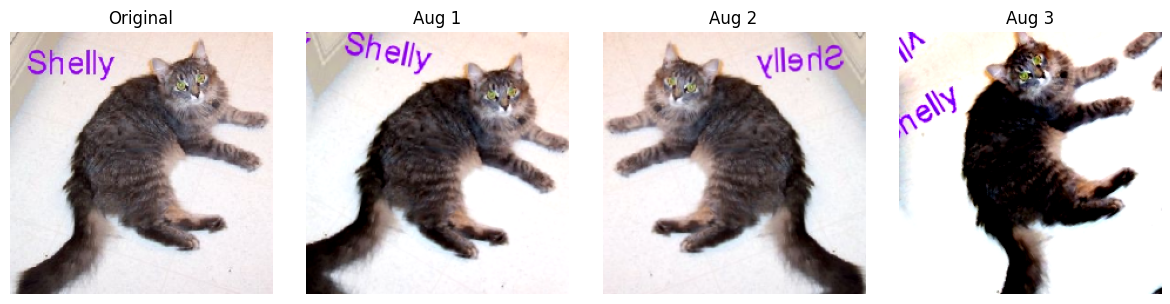

In [ ]:
sample_path = sorted((TRAIN_DIR / 'cats').glob('*.jpg'))[0]
sample_image = tf.keras.utils.load_img(sample_path, target_size=IMAGE_SIZE)
sample_array = tf.keras.utils.img_to_array(sample_image) / 255.0
sample_batch = tf.expand_dims(sample_array, 0)

preview_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.75),
], name="preview_augmentation")

augmented_images = [preview_augmentation(sample_batch, training=True)[0].numpy() for _ in range(3)]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample_array)
axes[0].set_title('Original')
axes[0].axis('off')

for ax, image, title in zip(axes[1:], augmented_images, ['Aug 1', 'Aug 2', 'Aug 3']):
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## MobileNetV2 baseline

Use a frozen pretrained backbone first

In [8]:
augmentation = make_augmentation()

base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,),
)
base_model.trainable = False

model = Sequential([
    layers.Input(shape=IMAGE_SIZE + (3,)),
    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),
    augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
], name='mobilenetv2_classifier')

model.summary()


Model: "mobilenetv2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

In [10]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks = make_callbacks('mobilenetv2_frozen'),
)


Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.7501 - loss: 0.4978 - val_accuracy: 0.9542 - val_loss: 0.2129
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 72s 233ms/step - accuracy: 0.8382 - loss: 0.3491 - val_accuracy: 0.9743 - val_loss: 0.1397
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 72s 233ms/step - accuracy: 0.8638 - loss: 0.3007 - val_accuracy: 0.9767 - val_loss: 0.1133
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 71s 233ms/step - accuracy: 0.8700 - loss: 0.2862 - val_accuracy: 0.9799 - val_loss: 0.0975
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 72s 233ms/step - accuracy: 0.8776 - loss: 0.2723 - val_accuracy: 0.9811 - val_loss: 0.0885
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 72s 233ms/step - accuracy: 0.8828 - loss: 0.2627 - val_accuracy: 0.9815 - val_loss: 0.0822
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 71s 233ms/step - accuracy: 0.8819 - loss: 0.2590 - val_accuracy: 0.9839 - val_loss: 0.0771
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 72s 233ms/step - accuracy: 0.8859 - loss: 

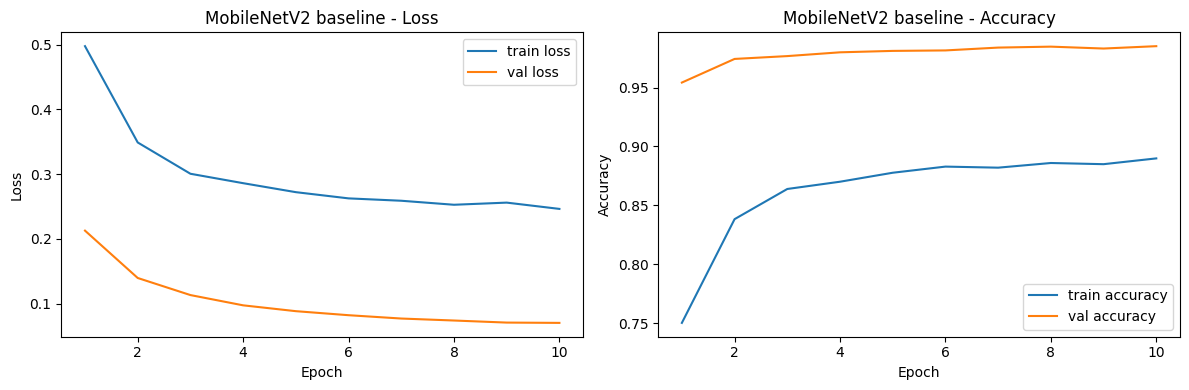

In [11]:
plot_learning(history, 'MobileNetV2 baseline')

## Fine-tune MobileNetV2

Unfreeze the top layers and train again with a smaller learning rate.

In [12]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss = 'binary_crossentropy',
    metrics=['accuracy'],
)

In [13]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks=make_callbacks('mobilenetv2_finetune'),
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 253ms/step - accuracy: 0.8981 - loss: 0.2306 - val_accuracy: 0.9868 - val_loss: 0.0468
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 142s 462ms/step - accuracy: 0.9073 - loss: 0.2079 - val_accuracy: 0.9884 - val_loss: 0.0401
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 138s 449ms/step - accuracy: 0.9150 - loss: 0.1944 - val_accuracy: 0.9876 - val_loss: 0.0396
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 150s 475ms/step - accuracy: 0.9192 - loss: 0.1842 - val_accuracy: 0.9868 - val_loss: 0.0400
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 96s 312ms/step - accuracy: 0.9249 - loss: 0.1756 - val_accuracy: 0.9868 - val_loss: 0.0366
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 138s 450ms/step - accuracy: 0.9268 - loss: 0.1681 - val_accuracy: 0.9872 - val_loss: 0.0366
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 154s 501ms/step - accuracy: 0.9285 - loss: 0.1648 - val_accuracy: 0.9872 - val_loss: 0.0393


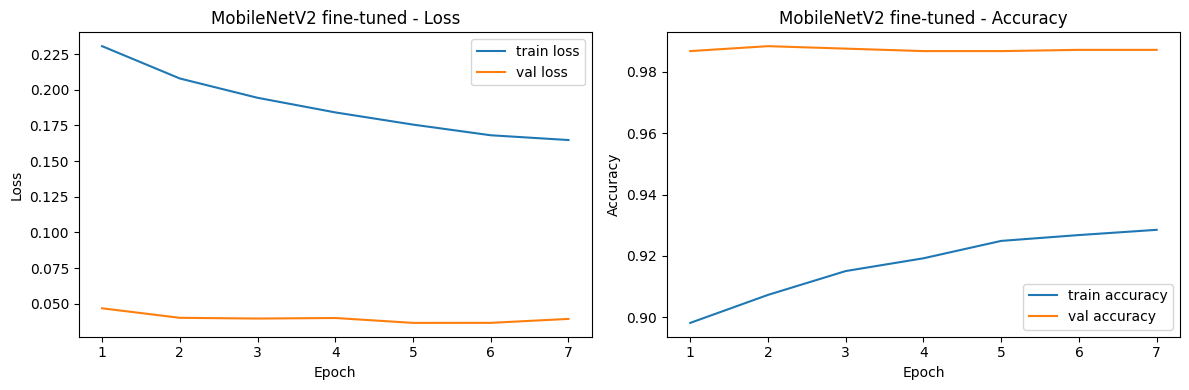

39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 203ms/step - accuracy: 0.9892 - loss: 0.0351
[0.03506121784448624, 0.9891696572303772]


In [14]:
plot_learning(history, 'MobileNetV2 fine-tuned')
test_metrics = model.evaluate(test_ds)
print(test_metrics)

## Custom ImageLoader


In [26]:
from PIL import Image, ImageEnhance, ImageOps

class ImageLoader(keras.utils.Sequence):
    def __init__(self, directory, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, augment=False, shuffle=True):
        super().__init__()
        self.directory = Path(directory)
        self.batch_size = batch_size
        self.image_size = image_size
        self.augment = augment
        self.shuffle = shuffle
        self.supported_extensions = {'.jpg', '.jpeg', '.png'}
        self.image_paths = []
        self.labels = []

        for class_name in CLASS_NAMES:
            class_dir = self.directory / class_name
            for image_file in sorted(class_dir.rglob('*')):
                if image_file.suffix.lower() not in self.supported_extensions:
                    continue
                try:
                    with Image.open(image_file) as image:
                        image.verify()
                except Exception:
                    continue
                self.image_paths.append(image_file)
                self.labels.append(CLASS_NAMES.index(class_name))

        self.indexes = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def _augment_image(self, image):
        if np.random.rand() < 0.5:
            image = ImageOps.mirror(image)
        if np.random.rand() < 0.3:
            image = image.rotate(np.random.uniform(-20, 20))
        if np.random.rand() < 0.3:
            image = ImageEnhance.Brightness(image).enhance(np.random.uniform(0.8, 1.2))
        if np.random.rand() < 0.3:
            image = ImageEnhance.Contrast(image).enhance(np.random.uniform(0.8, 1.2))
        return image

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_images = []
        batch_labels = []

        for idx in batch_indexes:
            image_path = self.image_paths[idx]
            try:
                with Image.open(image_path) as image:
                    image = image.convert('RGB')
                    image = image.resize(self.image_size)

                    if self.augment:
                        image = self._augment_image(image)

                    image = np.array(image, dtype=np.float32)
                    batch_images.append(image)
                    batch_labels.append(self.labels[idx])
            except Exception:
                continue

        if not batch_images:
            raise ValueError(f'No valid images found in batch {index}.')

        return np.stack(batch_images), np.array(batch_labels, dtype=np.float32)


train_ds = ImageLoader(TRAIN_DIR, augment=True, shuffle=True)
val_ds = ImageLoader(VAL_DIR, augment=False, shuffle=False)
test_ds = ImageLoader(TEST_DIR, augment=False, shuffle=False)

print('Custom training batches:', len(train_ds))
print('Custom validation batches:', len(val_ds))
print('Custom test batches:', len(test_ds))


Custom training batches: 307
Custom validation batches: 39
Custom test batches: 39


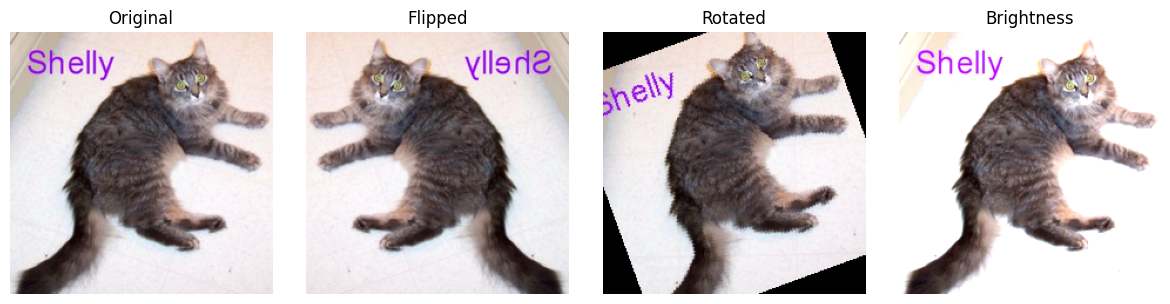

In [27]:
sample_path = train_ds.image_paths[0]
image = Image.open(sample_path).convert('RGB').resize(IMAGE_SIZE)
flip_image = ImageOps.mirror(image)
rotate_image = image.rotate(20)
brightness_image = ImageEnhance.Brightness(image).enhance(1.3)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
images = [image, flip_image, rotate_image, brightness_image]
titles = ['Original', 'Flipped', 'Rotated', 'Brightness']

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [28]:
augmentation = make_augmentation()

base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=IMAGE_SIZE + (3,),
)
base_model.trainable = False

model = Sequential([
    layers.Input(shape=IMAGE_SIZE + (3,)),
    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),
    augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
], name='custom_mobilenetv2_classifier')

model.summary()

Model: "custom_mobilenetv2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-4),
    loss = 'binary_crossentropy',
    metrics = ['accuracy'],
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 90s 285ms/step - accuracy: 0.7234 - loss: 0.5368 - val_accuracy: 0.9450 - val_loss: 0.2378
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 87s 284ms/step - accuracy: 0.8322 - loss: 0.3691 - val_accuracy: 0.9655 - val_loss: 0.1482
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 87s 283ms/step - accuracy: 0.8496 - loss: 0.3242 - val_accuracy: 0.9699 - val_loss: 0.1171
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 88s 285ms/step - accuracy: 0.8595 - loss: 0.3053 - val_accuracy: 0.9751 - val_loss: 0.0999
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 87s 283ms/step - accuracy: 0.8695 - loss: 0.2900 - val_accuracy: 0.9763 - val_loss: 0.0920
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 87s 283ms/step - accuracy: 0.8726 - loss: 0.2829 - val_accuracy: 0.9767 - val_loss: 0.0854
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 87s 283ms/step - accuracy: 0.8767 - loss: 0.2746 - val_accuracy: 0.9763 - val_loss: 0.0811
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 87s 283ms/step - accuracy: 0.8787 - loss: 0

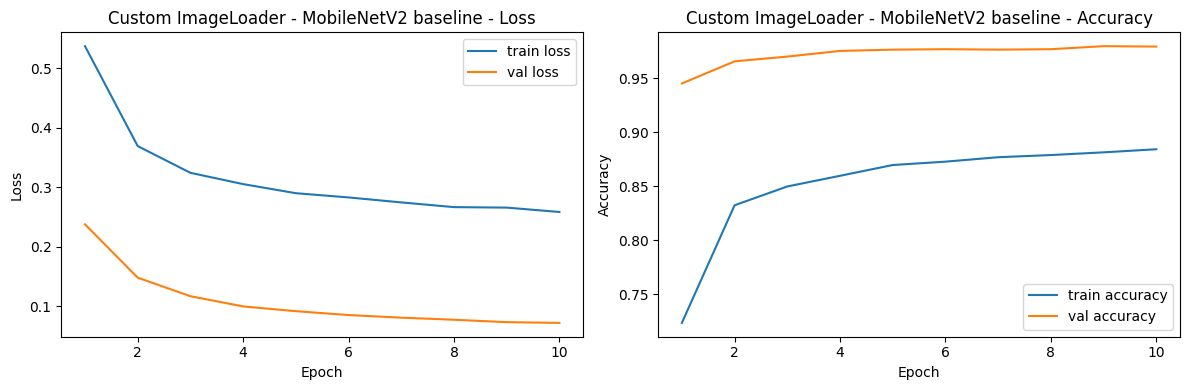

In [31]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks = make_callbacks('custom_mobilenetv2_frozen'),
)

plot_learning(history, 'Custom ImageLoader - MobileNetV2 baseline')

## Custom ImageLoader Fine Tuned

In [32]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-5),
    loss = 'binary_crossentropy',
    metrics = ['accuracy'],
)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 99s 317ms/step - accuracy: 0.8920 - loss: 0.2450 - val_accuracy: 0.9843 - val_loss: 0.0505
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 96s 312ms/step - accuracy: 0.9037 - loss: 0.2165 - val_accuracy: 0.9847 - val_loss: 0.0446
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 98s 318ms/step - accuracy: 0.9100 - loss: 0.2049 - val_accuracy: 0.9839 - val_loss: 0.0445
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 99s 323ms/step - accuracy: 0.9114 - loss: 0.2002 - val_accuracy: 0.9859 - val_loss: 0.0416
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 107s 350ms/step - accuracy: 0.9151 - loss: 0.1924 - val_accuracy: 0.9876 - val_loss: 0.0375
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 112s 366ms/step - accuracy: 0.9217 - loss: 0.1839 - val_accuracy: 0.9855 - val_loss: 0.0425
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 124s 403ms/step - accuracy: 0.9228 - loss: 0.1762 - val_accuracy: 0.9843 - val_loss: 0.0428


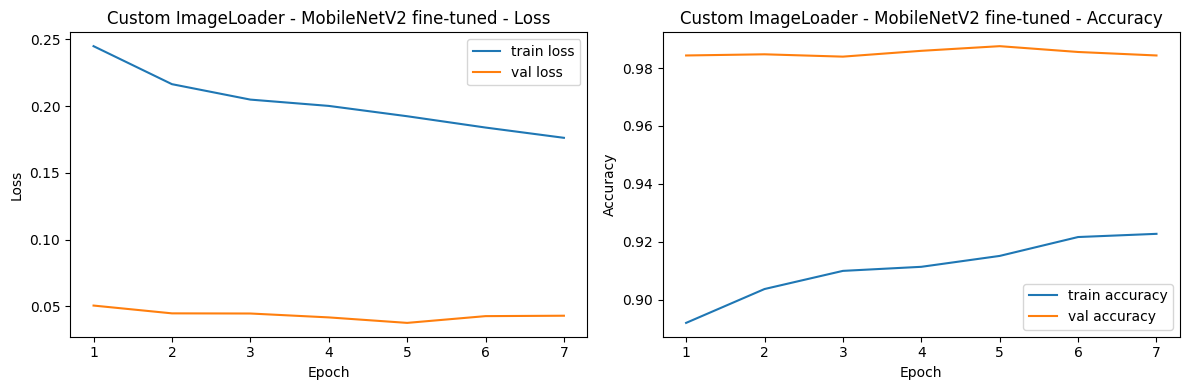

39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - accuracy: 0.9880 - loss: 0.0349
[0.03494648635387421, 0.9879662990570068]


In [33]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    callbacks = make_callbacks('custom_mobilenetv2_finetune'),
)

plot_learning(history, 'Custom ImageLoader - MobileNetV2 fine-tuned')
test_metrics = model.evaluate(test_ds)
print(test_metrics)

In [34]:
from tensorboard import program
import webbrowser

tb = program.TensorBoard()
tb.configure(argv = ['', '--logdir', 'outputs/logs', '--host', '127.0.0.1', '--port', '0'])
tb_url = tb.launch()
print(f'TensorBoard running at {tb_url}')
webbrowser.open_new_tab(tb_url)

C:\Users\Matt Shaver\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tensorboard\data\server_ingester.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


TensorBoard running at http://127.0.0.1:61715/


True